In [1]:
from pathlib import Path
import json
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'liar_binary.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'

for path in [MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

Use the original LIAR train/valid/test split to avoid accidental data leakage between training and evaluation.

In [3]:
df = pd.read_csv(DATA_PATH)

train_df = df[df['split'] == 'train'].copy()
valid_df = df[df['split'] == 'valid'].copy()
test_df = df[df['split'] == 'test'].copy()

X_train = train_df['statement'].fillna('')
y_train = train_df['label']

X_valid = valid_df['statement'].fillna('')
y_valid = valid_df['label']

X_test = test_df['statement'].fillna('')
y_test = test_df['label']

label_names = ['not_credible', 'credible']

In [4]:
def evaluate_binary_model(name: str, y_true, y_pred) -> dict[str, float | str]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='binary',
        pos_label=1,
        zero_division=0,
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='macro',
        zero_division=0,
    )
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_credible': precision,
        'recall_credible': recall,
        'f1_credible': f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
    }

In [5]:
def save_confusion_matrix(y_true, y_pred, title: str, output_path: Path) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    display.plot(values_format='d')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

In [6]:
metrics_rows = []
prediction_frames = []

In [7]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

              precision    recall  f1-score   support

not_credible       0.55      1.00      0.71       553
    credible       0.00      0.00      0.00       449

    accuracy                           0.55      1002
   macro avg       0.28      0.50      0.36      1002
weighted avg       0.30      0.55      0.39      1002



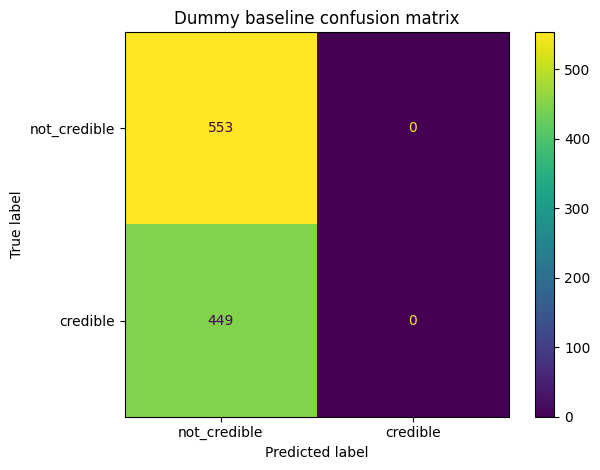

In [8]:
metrics_rows.append(evaluate_binary_model('Dummy baseline', y_test, dummy_pred))
print(classification_report(y_test, dummy_pred, target_names=label_names, zero_division=0))

save_confusion_matrix(
    y_test,
    dummy_pred,
    'Dummy baseline confusion matrix',
    FIGURES_DIR / 'confusion_matrix_dummy.png',
)

In [9]:
joblib.dump(dummy, MODELS_DIR / 'dummy_baseline.joblib')
print(f"Sanity check! Dummy model file was succesfully saved: {os.path.exists(MODELS_DIR / 'dummy_baseline.joblib')}")

Sanity check! Dummy model file was succesfully saved: True


The majority-class dummy model is a minimum reference point and helps verify whether later models learn any claim-level signal beyond class imbalance.